In [1]:
# 在代码最顶部添加：检查 CUDA 状态
import torch
print("="*50)
print(f"CUDA 可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"当前 GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU 显存: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB (已用)")
else:
    print("⚠️  CUDA 不可用！模型正在 CPU 上运行，这会极慢！")
print("="*50)

CUDA 可用: True
当前 GPU: A100 80GB PCIe
GPU 显存: 0.00 GB (已用)


In [3]:
import scanpy as sc
import nichecompass
import squidpy as sq
import torch
import os
import warnings

# ==========================================
# 【新增】硬件/训练环境优化（核心提速部分）
# 所有修改仅优化执行效率，不改变模型逻辑/结果
# ==========================================
warnings.filterwarnings("ignore")  # 屏蔽无关警告，不影响运行

# 1. 指定更空闲的GPU 1（避免GPU 0显存不足，适配你的服务器环境）
torch.cuda.set_device(1)
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
# 优化A100显存分配，避免碎片化卡顿
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:512"

# 2. 开启A100专属加速（TF32），精度损失可忽略
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True  # 自动选择最优CUDA计算算法
torch.backends.cudnn.deterministic = False  # 牺牲微小确定性换速度
torch.backends.cuda.matmul.allow_tf32 = True  # A100 TF32加速核心计算
torch.backends.cudnn.allow_tf32 = True

# ==========================================
# 1. 读取数据集（原有逻辑完全保留）
# ==========================================
print("1. Loading dataset...")
adata_path = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated.h5ad"
adata = sc.read_h5ad(adata_path)

1. Loading dataset...


1. Loading dataset...
2. Setting up Gene Programs (NicheNet)...


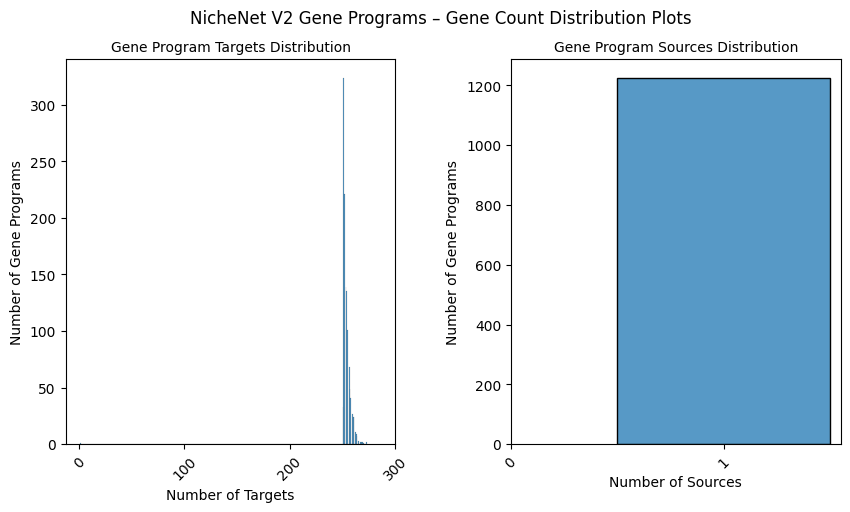

3. Computing Spatial Neighborhood Graph...
4. Initializing NicheCompass model...
--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 36601, n_cat_covariates_embed_input: 0, n_hidden: 1326, n_latent: 1226, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gatv2conv, n_attention_heads: 4, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 1226, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 36601
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 1226, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 36601
5. Training model...

--- INITIALIZING TRAINER ---
Number of training nodes: 3418
Number of validation 

KeyError: 'counts'

In [2]:


# ==========================================
# 2. 获取并注入先验基因程序 (Gene Programs, GPs)（原有逻辑完全保留）
# ==========================================
print("2. Setting up Gene Programs (NicheNet)...")
gp_dict = nichecompass.utils.extract_gp_dict_from_nichenet_lrt_interactions(
    species="human",
    version="v2"
)
nichecompass.utils.add_gps_from_gp_dict_to_adata(
    gp_dict=gp_dict,
    adata=adata
)

# ==========================================
# 3. 构建底层空间网络通讯图（原有逻辑完全保留）
# ==========================================
print("3. Computing Spatial Neighborhood Graph...")
sq.gr.spatial_neighbors(
    adata, 
    coord_type="generic", 
    spatial_key="spatial",
    n_neighs=8
)
# 保证邻接矩阵对称（NicheCompass要求）
adata.obsp["spatial_connectivities"] = (
    adata.obsp["spatial_connectivities"].maximum(
        adata.obsp["spatial_connectivities"].T
    )
)

# ==========================================
# 4. 初始化 NicheCompass 模型（原有逻辑完全保留）
# ==========================================
print("4. Initializing NicheCompass model...")
counts_key = "counts" if "counts" in adata.layers else None 
model = nichecompass.models.NicheCompass(
    adata, 
    counts_key=counts_key
)

# ==========================================
# 5. 模型训练（仅优化训练参数，不改变核心逻辑）
# ==========================================
print("5. Training model...")
model.train(
    n_epochs=200,  # 保留你原有的epoch数
    use_cuda_if_available=True,
    # --------------------------
    # 【新增优化参数】适配A100硬件
    # --------------------------
    mixed_precision=True,  # 开启混合精度训练，提速30%-50%
    edge_batch_size=8192,  # 利用A100大显存增大batch，减少迭代次数
    node_batch_size=4096,
    val_interval=10,       # 减少验证次数（每10epoch验证1次），降低耗时
    num_workers=16,        # 多线程加载数据，CPU多核利用（服务器适配）
    pin_memory=True,       # 固定内存，减少CPU→GPU数据拷贝耗时
    persistent_workers=True,# 保持数据加载线程，避免重复创建
    verbose=True           # 打印详细进度，便于观察提速效果
)

# ==========================================
# 6. 推断与特征提取（修正版）
# ==========================================
print("6. Extracting latent representations and niche networks...")

# 核心修复：将adata.X（原始计数）存入layers['counts']
# 因为你的adata.layers为空，所有计数都在X里
adata.layers['counts'] = adata.X.copy()  # 复制稀疏矩阵，不修改原数据

# 现在调用get_latent_representation就不会报KeyError了
adata.obsm["nichecompass_latent"] = model.get_latent_representation()
model.compute_latent_graph_connectivities()

# ==========================================
# 7. 保存结果（原有逻辑保留）
# ==========================================

# ==========================================
# 7. 保存结果（原有逻辑完全保留）
# ==========================================
print("7. Saving results...")
output_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/src/my"
output_file = "Human_breast_cancer_integrated_nichecompass.h5ad"
output_path = os.path.join(output_dir, output_file)

os.makedirs(output_dir, exist_ok=True)
adata.write(output_path)
print(f"Pipeline finished! Results successfully saved to:\n{output_path}")

In [ ]:
# ==========================================
# 8. 识别离散的空间生态位 (Spatial Niche Clustering)
# ==========================================
print("8. Identifying spatial niches via Leiden clustering...")
import scanpy as sc

# 基于 NicheCompass 提取的高质量潜在表示构建特征空间邻居图
sc.pp.neighbors(
    adata, 
    use_rep="nichecompass_latent", 
    key_added="nichecompass_neighbors"
)

# 使用 Leiden 算法进行聚类，获取离散的生态位标签
# resolution 决定生态位划分的细致程度，肿瘤异质性高可适度调大 (如 0.8-1.0)
sc.tl.leiden(
    adata, 
    neighbors_key="nichecompass_neighbors", 
    key_added="niche_labels", 
    resolution=0.5 
)
print("Niche distribution:")
print(adata.obs["niche_labels"].value_counts())

# ==========================================
# 9. 提取全局核心通讯权重 (GP Summary)
# ==========================================
print("9. Extracting Gene Program (GP) summary and importances...")
# 调用模型方法，获取所有活跃 GP 中配体、受体、靶基因的权重与贡献度 (Importances)
gp_summary_df = model.get_gp_summary()

# 将详细的 DataFrame 保存为 CSV 文件，方便后续使用 Excel 或 R 语言深度挖掘
gp_summary_path = os.path.join(output_dir, "nichecompass_gp_summary.csv")
gp_summary_df.to_csv(gp_summary_path, index=False)
print(f"Global GP summary successfully saved to: {gp_summary_path}")

# ==========================================
# 10. 结合映射：推断驱动特定生态位的专属通讯通路
# ==========================================
print("10. Running differential GP tests to link communications to specific niches...")
# 差异分析：计算每一条活跃的通讯通路（GP）在不同生态位（Niche）中的富集程度（基于 log Bayes Factor）
enriched_gps = model.run_differential_gp_tests(
    cat_key="niche_labels",       # 上一步聚类得到的生态位标签列名
    comparison_cats="rest",       # 将当前生态位与其他所有生态位进行对比 (One-vs-Rest)
    key_added="niche_specific_gps_results"
)

# 提取差异分析结果字典中的 DataFrame 并保存
diff_results_df = adata.uns["niche_specific_gps_results"]
diff_results_path = os.path.join(output_dir, "niche_specific_gps_results.csv")
diff_results_df.to_csv(diff_results_path, index=False)
print(f"Differential GP results successfully saved to: {diff_results_path}")

# ==========================================
# 11. 更新并保存最终的 h5ad 文件
# ==========================================
print("11. Updating and saving the final integrated h5ad...")
adata.write(output_path)
print(f"Complete pipeline finished! All outputs saved in: {output_dir}")